# Spaceship Titanic

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [17]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (8693, 14)
Test Shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Exploratory Data Analysis

In [18]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 1.2+ MB


In [19]:
missing = train_df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
dtype: int64

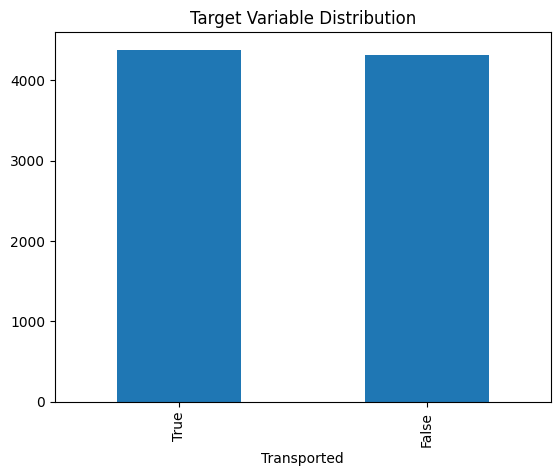

In [20]:
train_df['Transported'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.show()

## Data Preprocessing

In [21]:
bool_cols = ['CryoSleep', 'VIP']

for col in bool_cols:
    train_df[col] = train_df[col].astype('object')
    test_df[col] = test_df[col].astype('object')

X = train_df.drop('Transported', axis=1)
y = train_df['Transported']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='str')
Categorical Features: Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP'], dtype='str')


## Preprocessing Pipelines

In [22]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Train Test Split

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Training

In [26]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        eval_metric='logloss',
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_valid)

    accuracy = accuracy_score(y_valid, preds)

    results.append([name, accuracy])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])

results_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,Gradient Boosting,0.799885
3,XGBoost,0.797585
0,Logistic Regression,0.786084
1,Random Forest,0.735480


## Best Model Evaluation

In [ ]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

preds = best_model.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, preds))

print("\nClassification Report:")
print(classification_report(y_valid, preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, preds))

Accuracy: 0.8021851638872916

Classification Report:
              precision    recall  f1-score   support

       False       0.81      0.78      0.80       863
        True       0.79      0.82      0.81       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739


Confusion Matrix:
[[673 190]
 [154 722]]


## Cross Validation

In [28]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:", scores.mean())

Cross Validation Scores:
[0.79125934 0.78378378 0.79010926 0.80552359 0.80667434]

Average Accuracy: 0.7954700630165215
